In [1]:
import scanpy as sc
import spatialdata as sd
import squidpy as sq
import pandas as pd
import seaborn as sns
from shapely.geometry import Polygon, Point

In [49]:
sdata = sd.read_zarr("Version 2 Baysor Zarr//Sample_1H_annotated.zarr")

In [3]:
sdata

SpatialData object with:
├── Images
│     ├── '1.4D.tiff': MultiscaleSpatialImage[cyx] (4, 837, 620), (4, 418, 310), (4, 209, 155), (4, 104, 77)
│     └── 'morphology_focus': MultiscaleSpatialImage[cyx] (1, 34041, 42647), (1, 17020, 21323), (1, 8510, 10661), (1, 4255, 5330), (1, 2127, 2665)
├── Labels
│     ├── 'cell_labels': MultiscaleSpatialImage[yx] (34041, 42647), (17020, 21323), (8510, 10661), (4255, 5330), (2127, 2665)
│     └── 'nucleus_labels': MultiscaleSpatialImage[yx] (34041, 42647), (17020, 21323), (8510, 10661), (4255, 5330), (2127, 2665)
├── Points
│     └── 'transcripts': DataFrame with shape: (1654574, 10) (3D points)
├── Shapes
│     ├── 'Fibrous_cap': GeoDataFrame shape: (1, 1) (2D shapes)
│     ├── 'Intima': GeoDataFrame shape: (1, 1) (2D shapes)
│     ├── 'Media': GeoDataFrame shape: (1, 1) (2D shapes)
│     ├── 'Necrotic_core': GeoDataFrame shape: (1, 1) (2D shapes)
│     ├── 'Thrombus': GeoDataFrame shape: (1, 1) (2D shapes)
│     ├── 'cell_boundaries': GeoDataFra

In [4]:
adata = sc.read_10x_mtx("Baysor_segmentation//4D_baysor_mtx")

In [5]:
adata.obs.index = adata.obs.index.str.replace(r'^[^_]+_', '', regex=True)

In [6]:
df = pd.read_csv("Baysor_segmentation//4D_cells//segmentation_cell_stats.csv")

In [7]:
df.set_index('cell', inplace=True, drop=False)

In [8]:
df.index.name = None

In [9]:
adata.obs = adata.obs.merge(df, left_index=True, right_index=True, how='outer')

In [10]:
adata.obsm["spatial"] = adata.obs[['x', 'y']].values

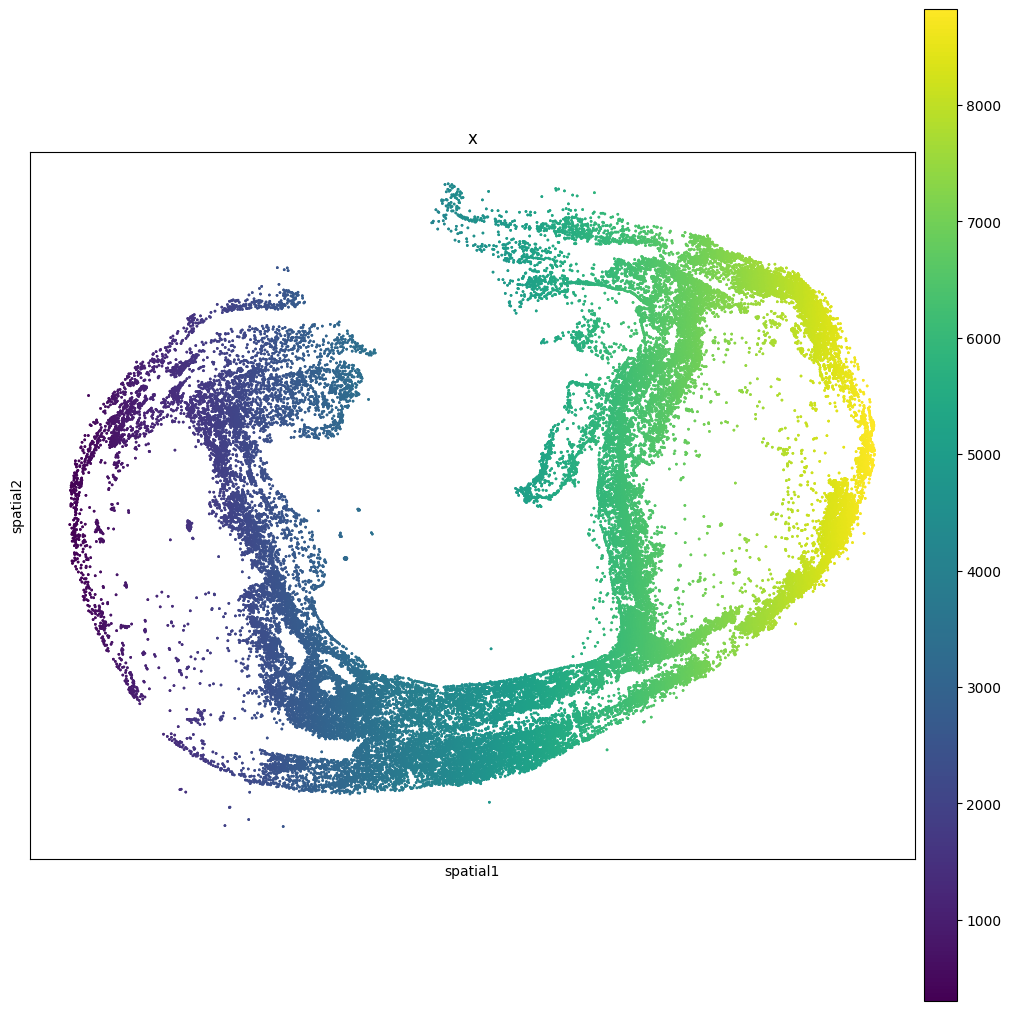

In [48]:
sq.pl.spatial_scatter(
    adata, color=["x"], shape=None, figsize=(10, 10)
)

In [12]:
sdata.tables["Baysor"] = adata

In [15]:
cell_coords = sdata.tables["Baysor"].obsm["spatial"]
Intima = sdata.shapes["Intima"].iloc[0, 0]
#Intima_2 = sdata.shapes["Intima_2"].iloc[0, 0]
Media = sdata.shapes["Media"].iloc[0, 0]
Thrombus = sdata.shapes["Thrombus"].iloc[0, 0]
Fibrous_cap = sdata.shapes["Fibrous_cap"].iloc[0, 0]
Necrotic_core = sdata.shapes["Necrotic_core"].iloc[0, 0]

In [39]:
def get_region(point, Intima, Media, Thrombus, Fibrous_cap, Necrotic_core):
    point = Point(point)
    if Thrombus.contains(point):
       return "Thrombus"
    elif Fibrous_cap.contains(point) and not Thrombus.contains(point):
        return "Fibrous_cap"
    if Necrotic_core.contains(point) and not Fibrous_cap.contains(point) and not Thrombus.contains(point):
        return "Necrotic_core"
    #elif Intima_2.contains(point):
    #    return "Intima_2"
    elif Intima.contains(point) and not Fibrous_cap.contains(point) and not Thrombus.contains(point) and not Necrotic_core.contains(point):
        return "Intima"
    elif Media.contains(point) and not Intima.contains(point) and not Fibrous_cap.contains(point) and not Thrombus.contains(point) and not Necrotic_core.contains(point):
        return "Media"
    else:
        return "None"

In [40]:
sdata.tables["Baysor"].obs['plaque_region'] = [get_region(coord, Intima, Media, Thrombus, Fibrous_cap, Necrotic_core) for coord in cell_coords]
sdata.tables["Baysor"].obs['plaque_region'] = sdata.tables["Baysor"].obs['plaque_region'].astype('category')

In [24]:
sdata.tables["Baysor"]

AnnData object with n_obs × n_vars = 34747 × 345
    obs: 'cell', 'x', 'y', 'z', 'cluster', 'n_transcripts', 'density', 'elongation', 'area', 'avg_confidence', 'avg_assignment_confidence', 'max_cluster_frac', 'lifespan', 'plaque_region'
    var: 'gene_ids', 'feature_types'
    obsm: 'spatial'

In [33]:
def find_closest_region(point, polygon1, polygon2, polygon3, polygon4, polygon5):
    point = Point(point)
    dist_to_region1 = point.distance(polygon1)
    dist_to_region2 = point.distance(polygon2)
    dist_to_region3 = point.distance(polygon3)
    dist_to_region4 = point.distance(polygon4)
    dist_to_region5 = point.distance(polygon5)
    distance_to_region_list = [(dist_to_region1, "Intima"), (dist_to_region2, "Media"), (dist_to_region3, "Thrombus"), (dist_to_region4, "Fibrous_cap"), (dist_to_region5, "Necrotic_core")]
    smallest_distance, closest_polygon = min(distance_to_region_list, key=lambda x: x[0])
    return closest_polygon

In [41]:
count = 0
for i, row in sdata.tables["Baysor"].obs.iterrows():
    if row['plaque_region'] == 'None':
        sdata.tables["Baysor"].obs.at[i, 'plaque_region'] = find_closest_region(cell_coords[count], Intima, Media, Thrombus, Fibrous_cap, Necrotic_core)
    count += 1

C:\Users\laure\Desktop\github\spatial_de\squidpy\src\squidpy\pl\_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


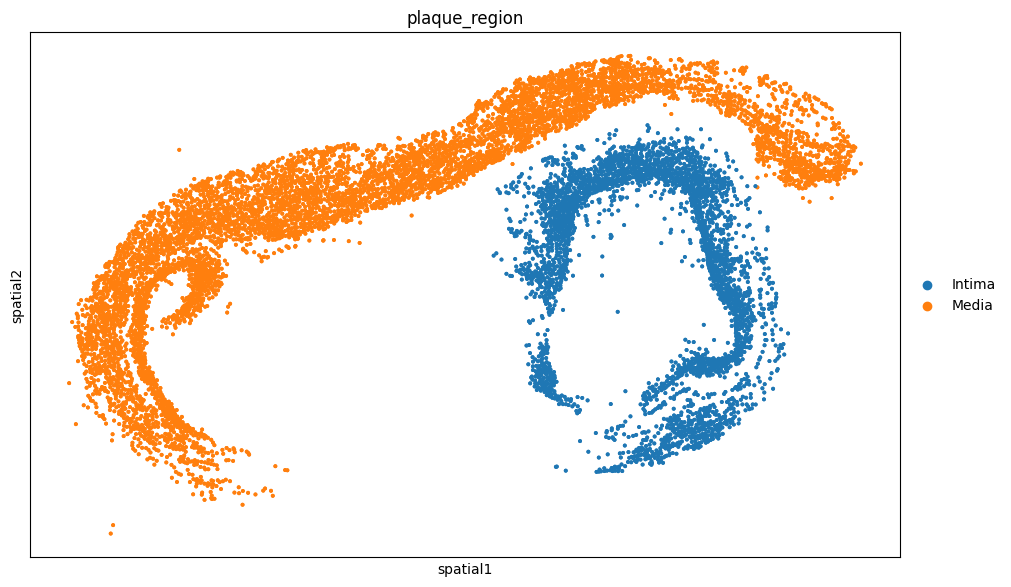

In [50]:
sq.pl.spatial_scatter(
    sdata.tables["Baysor"], color=["plaque_region"], shape=None, figsize=(10, 10)
)

In [43]:
sdata.tables["Baysor"].obs["plaque_region"] = sdata.tables["Baysor"].obs["plaque_region"].cat.remove_categories(['None'])
del sdata.tables["Baysor"].uns['plaque_region_colors']

In [44]:
sdata.tables["Baysor"].obs["plaque_region"].unique()

['Media', 'Necrotic_core', 'Thrombus', 'Intima', 'Fibrous_cap']
Categories (5, object): ['Fibrous_cap', 'Intima', 'Media', 'Necrotic_core', 'Thrombus']

In [46]:
sdata.write("Version 2 Baysor Zarr//Sample_4D_annotated.zarr", overwrite=True)

INFO     The Zarr file used for backing will now change from Version 2 Zarr\Sample_4D_annotated.zarr to Version 2  
         Baysor Zarr\Sample_4D_annotated.zarr                                                                      
